In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import functools
from pathlib import Path
import itertools as itt

import distinctipy
from scipy.stats import pearsonr, spearmanr, kendalltau
import umap

from dti import data
from dti.utils import scaffold_split, umap_split, init_logging
from dti.constants import SMILES, ASSAY, ACT

init_logging()
sns.set_context("talk")

17:42:13 [INFO] logging run 1742055871.4955633 to data/output/1742055871.4955633/output.log
17:42:13 [INFO] logging run 1742055871.4955633 to data/output/1742055871.4955633/output.log


In [2]:
data_path = Path("..") / "data" / "raw"

In [3]:
# df = data.load_nci(data_path / "atcc.csv")
df = data.load_kinodata(data_path / "act

17:24:31 [INFO] loading NCI ATCC data from ../data/raw/atcc.csv


In [31]:
df = data.load_kinodata(data_path / "activities-chembl33_v0.5.csv")

17:42:15 [INFO] loading kinodata activities from ../data/raw/activities-chembl33_v0.5.csv
17:42:15 [INFO] loading kinodata activities from ../data/raw/activities-chembl33_v0.5.csv


In [34]:
from multiprocessing import Pool
from dti.utils import compute_fp
with Pool(8) as p:
    fp_list = p.map(compute_fp, df[SMILES].values)

In [35]:
df = df[[fp is not None for fp in fp_list]]

In [36]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

pca = PCA(n_components=15)
fp_list = [fp for fp in fp_list if fp is not None]
pcs = pca.fit_transform(np.stack(fp_list))

In [37]:
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(pcs)

/home/michael/Code/hodge-dti/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/michael/Code/hodge-dti/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/michael/Code/hodge-dti/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/michael/Code/hodge-dti/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is

In [44]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=10)  # Adjust size as needed
df['_umap'] = clusterer.fit_predict(embedding)

/home/michael/Code/hodge-dti/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/michael/Code/hodge-dti/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [38]:
# logger.info("umap split: Agglomerative clustering")
ac = AgglomerativeClustering(n_clusters=5, compute_full_tree=False)
ac.fit_predict(embedding)
data['_umap'] = ac.labels_

MemoryError: Unable to allocate 121. GiB for an array with shape (16196670171,) and data type float64

In [45]:
for test_cluster in range(5):
    df_train, df_test = df[df['_umap'] != test_cluster], df[df['_umap'] == test_cluster]
    
    training_mean = df_train[ACT].mean()
    predictor = df_train.groupby(ASSAY)[[ACT]].agg("mean")
    df_test = df_test.join(
        predictor.rename(columns={ACT: "assay_mean"}), on=ASSAY, how="left"
    )
    
    xs, ys = df_test["activity_value"].values, df_test["assay_mean"].values
    xs = xs[~np.isnan(ys)]
    ys = ys[~np.isnan(ys)]
    assert np.all(~np.isnan(xs))
    mae = np.abs(xs - ys).mean()
    pr = pearsonr(xs, ys).statistic
    kt = kendalltau(xs, ys).statistic
    sr = spearmanr(xs, ys).statistic
    print('===', test_cluster)
    print(f"Pearson={pr:.2f}\nSpearman={sr:.2f}\nMAE={mae:.2f}\nKendall's tau={kt:.2f}")

=== 0
Pearson=0.53
Spearman=0.57
MAE=0.81
Kendall's tau=0.39
=== 1
Pearson=0.70
Spearman=0.70
MAE=1.59
Kendall's tau=0.55
=== 2
Pearson=0.50
Spearman=0.59
MAE=0.84
Kendall's tau=0.42
=== 3
Pearson=0.88
Spearman=0.68
MAE=0.30
Kendall's tau=0.54
=== 4
Pearson=0.72
Spearman=0.66
MAE=0.60
Kendall's tau=0.50


In [42]:
df_test.corr(numeric_only=True)

,compound_id,activity_value,assay_id,_umap,assay_mean
compound_id,1.000000,-0.010305,-0.023334,NaN,-0.038061
activity_value,-0.010305,1.000000,0.114937,NaN,0.351737
assay_id,-0.023334,0.114937,1.000000,NaN,0.151496
_umap,NaN,NaN,NaN,NaN,NaN
assay_mean,-0.038061,0.351737,0.151496,NaN,1.000000


R2=0.35
Spearman=0.41
MAE=0.65
Kendall's tau=0.29


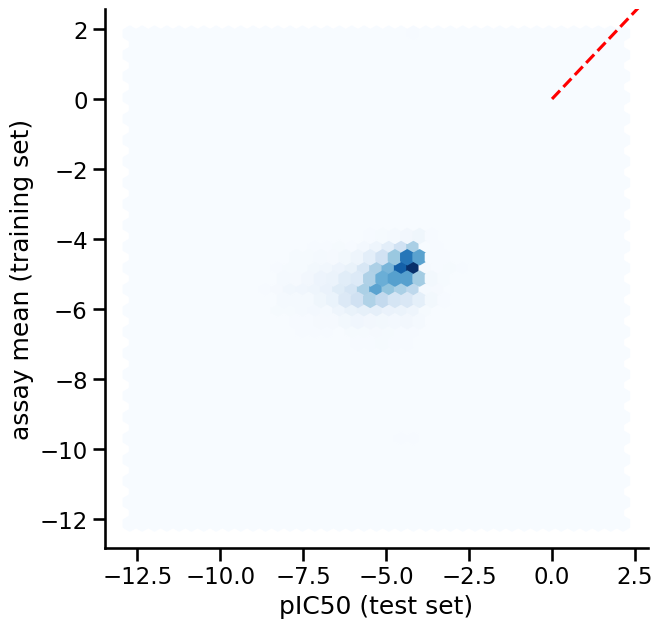

In [43]:
plt.figure(figsize=(7, 7))
xs, ys = df_test["activity_value"].values, df_test["assay_mean"].values
plt.hexbin(xs, ys, gridsize=40, cmap="Blues")
sns.despine()
xl = plt.xlim()
yl = plt.ylim()
plt.plot([0, 15], [0, 15], "r--")
plt.xlim(*xl)
plt.ylim(*yl)
plt.ylabel("assay mean (training set)")
plt.xlabel("pIC50 (test set)")
xs = xs[~np.isnan(ys)]
ys = ys[~np.isnan(ys)]
assert np.all(~np.isnan(xs))
mae = np.abs(xs - ys).mean()
pr = pearsonr(xs, ys).statistic
kt = kendalltau(xs, ys).statistic
sr = spearmanr(xs, ys).statistic
print(f"R2={pr:.2f}\nSpearman={sr:.2f}\nMAE={mae:.2f}\nKendall's tau={kt:.2f}")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


def corrfunc(x, y, **kws):
    corr = spearmanr(x, y, nan_policy="omit").statistic
    ax = plt.gca()
    ax.annotate(
        f"ρ = {corr:.2f}",
        xy=(0.5, 0.5),
        xycoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
    )


cols = [ACT, "activities.activity_id", "docs.year", "compound_id", "assay_mean"]
df_filtered = df_test[df_test["docs.year"] > 1950][cols]

g = sns.PairGrid(df_filtered, corner=True)

g.map_lower(sns.scatterplot, s=5, alpha=0.5)
g.map_offdiag(corrfunc)
g.map_diag(sns.histplot, kde=True)

plt.tight_layout()
plt.savefig("pair.png")